C:\Users\MCA-Lab6\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 106s 118ms/step - accuracy: 0.4154 - loss: 1.6001 - val_accuracy: 0.5082 - val_loss: 1.3554
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.5448 - loss: 1.2772 - val_accuracy: 0.5472 - val_loss: 1.2922
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 103ms/step - accuracy: 0.6025 - loss: 1.1242 - val_accuracy: 0.6338 - val_loss: 1.0418
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step - accuracy: 0.6433 - loss: 1.0178 - val_accuracy: 0.6478 - val_loss: 0.9858
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 103ms/step - accuracy: 0.6718 - loss: 0.9387 - val_accuracy: 0.6678 - val_loss: 0.9578
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6601 - loss: 0.9788
Test Accuracy: 0.660099983215332


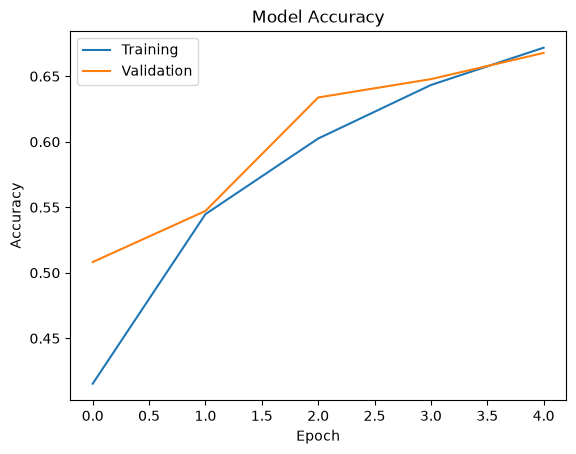

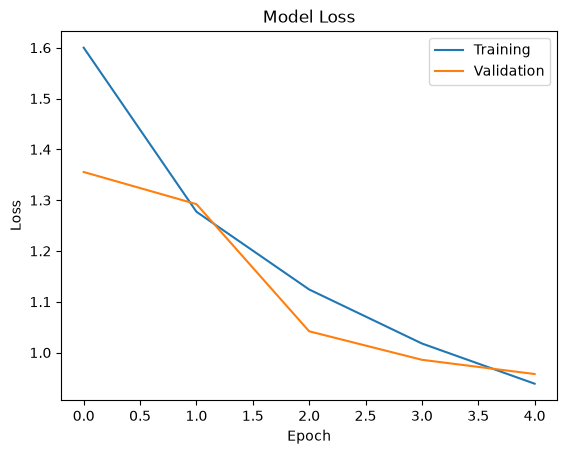

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.title("Model Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])
plt.title("Model Loss")
plt.show()